# Taller B5-T1 · Generación de datos financieros sintéticos
## Notebook 04 — La malla real × sintético

**Esta es la pregunta del taller.** Los notebooks anteriores construyeron las piezas: el
dataset con splits purgados (01), la arquitectura downstream congelada y los baselines
clásicos (02), y seis generadores auditados contra los hechos estilizados (03). Aquí se
responde: **¿cuántos datos sintéticos ayudan, en qué régimen de escasez de datos reales, y
qué generador los produce mejor?**

### El experimento

Para cada combinación (N_real, generador, ratio, semilla):

1. Se submuestrean `N_real` ventanas del train.
2. El generador se **reentrena con esas `N_real` ventanas y solo esas**.
3. Se generan `N_synth = ratio × N_real` ventanas sintéticas.
4. Se entrena la arquitectura **congelada** del notebook 02 sobre la mezcla.
5. Se evalúa en el **test real**, intocado y siempre el mismo.

### Las cuatro reglas que hacen esto interpretable

| Regla | Por qué |
|---|---|
| **El generador se reentrena en cada celda** | Ajustarlo con las 102k ventanas y luego *simular* escasez sería fuga: los sintéticos llevarían información de datos que el escenario declara no tener, y la curva saldría optimista. |
| **Submuestreo por fechas, no por filas** | En una fecha dada todas las ventanas del panel cuentan la misma historia de mercado. Un muestreo de filas daría un N nominal muy superior al efectivo. |
| **Validación siempre real** | Si el early-stopping mirase datos sintéticos, optimizaríamos la distribución equivocada. |
| **Arquitectura e hiperparámetros congelados** | Si una celda rinde distinto, la única explicación posible son los datos. |

> **Métrica principal: `delta_r2`** — la ganancia de R² en test de cada celda frente a la
> celda de *solo real* con el mismo N. Responde literalmente al enunciado: para el mismo
> presupuesto de datos reales, ¿cuánto añade el sintético? El umbral de relevancia lo fijó
> el notebook 02: **±0,006**, la dispersión entre semillas del modelo con datos reales.
> Cualquier efecto por debajo de eso es ruido de optimización, no señal.

## 0 · Setup y configuración de la malla

**Dos tamaños de malla.** `REDUCIDA` valida el pipeline y ya cubre el régimen de escasez,
que es donde está el hallazgo; `COMPLETA` añade el extremo de datos abundantes y el ratio
10×. La diferencia de coste es de ~6×, y sale casi entera de dos celdas: `N=10.000` con
`ratio=10` entrena sobre 110.000 ventanas, tanto como el dataset completo.

**Submuestreo de la validación.** La validación real tiene 17.146 ventanas y se evalúa en
cada época de cada celda: a N pequeño ese coste fijo **domina el tiempo total** de la malla
(medido: ~45 s por celda con N=300). Como su único papel es elegir la época de la que se
conservan los pesos, 5.000 ventanas reales bastan de sobra y el coste por celda cae unas
tres veces. Es una decisión de eficiencia que no toca ninguna comparación: la validación es
idéntica en todas las celdas.

In [1]:
import sys, json, time
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.config import Config, set_global_seed
from src.eda import PALETTE, _style
from src.malla import (plan_de_malla, ejecutar_malla, resumir, delta_vs_solo_real,
                       delta_pareado, umbral_ruido_por_n, SOLO_REAL)
from src.training import get_device

cfg = Config()
set_global_seed(cfg.seed)
device = get_device()
print("Device:", device)

# ---- Tamaño de la malla -------------------------------------------------
MALLA = "REDUCIDA"          # "REDUCIDA" o "COMPLETA"

CONFIG_MALLA = {
    "REDUCIDA": dict(n_reales=[250, 1000, 3000], ratios=[0, 1, 3], seeds=[0, 1, 2]),
    "COMPLETA": dict(n_reales=[250, 1000, 3000, 10000], ratios=[0, 1, 3, 10], seeds=[0, 1, 2]),
}[MALLA]

GENERADORES = ["jitter", "gaussiana", "block_bootstrap", "vae", "wgan_gp", "realnvp"]
N_VAL = 5000                # submuestra de validación (real) — ver nota arriba
RUTA_CSV = cfg.out_dir / f"malla_{MALLA.lower()}.csv"

print(f"Malla {MALLA}: {CONFIG_MALLA}")
print(f"Resultados -> {RUTA_CSV}")

Device: cuda
Malla REDUCIDA: {'n_reales': [250, 1000, 3000], 'ratios': [0, 1, 3], 'seeds': [0, 1, 2]}
Resultados -> C:\Users\diego\MIAX\15-generacion-datos-sinteticos\B5T1\Taller-M5T1---Datos-Sinteticos\data\processed\malla_reducida.csv


In [2]:
# ---- Datos: todo lo que la malla puede tocar ----------------------------
d   = np.load(cfg.out_dir / "windows_dataset.npz")
std = json.load(open(cfg.out_dir / "standardizer.json"))
ref = json.load(open(cfg.out_dir / "downstream_reference.json"))   # arquitectura CONGELADA
meta = pd.read_parquet(cfg.out_dir / "windows_meta.parquet")
meta_train = meta[meta.split == "train"].reset_index(drop=True)

S = lambda a, m, s: ((a - std[m]) / std[s]).astype(np.float32)

# validación real submuestreada, fija para TODAS las celdas
rng_val = np.random.default_rng(cfg.seed)
iv = rng_val.choice(len(d["X_val"]), min(N_VAL, len(d["X_val"])), replace=False)

CONTEXTO = dict(
    Xs_train=S(d["X_train"], "x_mu", "x_sd"), ys_train=S(d["y_train"], "y_mu", "y_sd"),
    meta_train=meta_train,
    Xs_val=S(d["X_val"], "x_mu", "x_sd")[iv], ys_val=S(d["y_val"], "y_mu", "y_sd")[iv],
    Xs_test=S(d["X_test"], "x_mu", "x_sd"), y_test_fisico=d["y_test"],
    std=std, ref=ref, device=device,
)

print(f"Arquitectura congelada: {ref['arch']} {ref['arch_kwargs']}")
print(f"Referencia con datos reales completos: R² test = "
      f"{np.mean([v['test_r2'] for v in ref['metricas_seeds'].values()]):.4f}")
print(f"train {meta_train.shape[0]:,} ventanas / {meta_train.date_t.nunique():,} fechas | "
      f"val {len(iv):,} (submuestra) | test {len(d['X_test']):,}")

Arquitectura congelada: cnn {'channels': [32, 64, 128], 'fc': 128}
Referencia con datos reales completos: R² test = 0.4569
train 102,406 ventanas / 2,372 fechas | val 5,000 (submuestra) | test 24,613


## 1 · Ejecución de la malla

El plan se ordena de **coste creciente**: si la ejecución se interrumpe, lo ya calculado es
el régimen de escasez, que es el que más importa. Cada celda se escribe al CSV en cuanto
termina, así que **relanzar esta celda reanuda donde se quedó** sin recalcular nada.

In [3]:
plan = plan_de_malla(generadores=GENERADORES, **CONFIG_MALLA)
print(f"{len(plan)} celdas en el plan "
      f"({len(CONFIG_MALLA['n_reales'])} niveles de N × "
      f"{len(CONFIG_MALLA['ratios'])} ratios × {len(GENERADORES)} generadores × "
      f"{len(CONFIG_MALLA['seeds'])} semillas)")

117 celdas en el plan (3 niveles de N × 3 ratios × 6 generadores × 3 semillas)


In [4]:
t0 = time.time()
df = ejecutar_malla(plan, RUTA_CSV, **CONTEXTO)
print(f"\nMalla terminada en {(time.time() - t0)/60:.1f} min | {len(df)} celdas en el CSV")

Malla: 117 celdas | ya hechas: 117 | pendientes: 0

Malla terminada en 0.0 min | 117 celdas en el CSV


## 2 · Resultados

### 2.1 Tabla resumen

In [5]:
resumen = resumir(df)
delta = delta_vs_solo_real(resumen)

# referencia de cada N: cuánto rinde el modelo con SOLO datos reales
print("Referencia — solo datos reales:")
display(resumen[resumen.generador == SOLO_REAL][["n_real", "test_r2_media", "test_r2_sd"]].round(4))

# tabla principal: ganancia frente a esa referencia
tabla = delta.pivot_table(index=["n_real", "generador"], columns="ratio", values="delta_r2")
tabla.round(4)

Referencia — solo datos reales:


,n_real,test_r2_media,test_r2_sd
6,250,0.2483,0.0634
19,1000,0.2740,0.0363
32,3000,0.3523,0.0299


ratio                      1.0     3.0
n_real generador                      
250    block_bootstrap -0.0240 -0.0677
       gaussiana       -0.0190 -0.0639
       jitter           0.0043  0.0040
       realnvp         -0.0150 -0.0234
       vae             -0.0073 -0.0344
       wgan_gp         -0.2685 -0.4041
1000   block_bootstrap -0.0034  0.0087
       gaussiana       -0.0272 -0.0518
       jitter           0.0285  0.0835
       realnvp          0.0467  0.0637
       vae             -0.0156 -0.0144
       wgan_gp         -0.0191  0.0163
3000   block_bootstrap  0.0065 -0.0181
       gaussiana       -0.0685 -0.0978
       jitter           0.0260  0.0261
       realnvp          0.0329  0.0312
       vae             -0.0437 -0.0665
       wgan_gp         -0.0831 -0.1239

### 2.1.b Análisis pareado: la comparación que sí es válida

**Corrección metodológica importante.** El notebook 02 fijó un umbral de relevancia de
±0,006 midiendo la dispersión entre semillas del modelo entrenado con las **102.406
ventanas reales completas**. Ese umbral **no vale aquí**: en régimen de escasez la
dispersión entre semillas es de 5 a 11 veces mayor, porque cada semilla sortea un
submuestreo distinto de datos reales y eso mueve el R² mucho más que cualquier efecto del
sintético.

La solución no es subir el umbral, sino **parear**. La semilla determina qué ventanas
reales "existen" en el escenario, así que comparamos cada celda contra la celda de
solo-real **de su misma semilla**: la varianza del submuestreo se cancela y queda solo el
efecto del dato sintético. Con 3 semillas exigimos |t| ≥ 2,5 para hablar de efecto; por
debajo, la celda se declara **no concluyente** en lugar de inventar una conclusión.

In [6]:
print("Dispersión entre semillas del modelo SOLO REAL (el umbral honesto en cada régimen):")
u = umbral_ruido_por_n(df)
display(pd.DataFrame({"sd_entre_semillas": u.round(4),
                      "veces el umbral del nb02 (0,006)": (u / 0.006).round(0)}))

par = delta_pareado(df)
print("\nΔ R² pareado por semilla — solo las celdas con veredicto:")
concluyentes = par[par.veredicto != "no concluyente"].sort_values("t")
display(concluyentes[["n_real", "generador", "ratio", "delta_medio", "ee", "t", "veredicto"]].round(4))
print(f"\n{len(par)} celdas: {(par.veredicto=='mejora').sum()} mejoran, "
      f"{(par.veredicto=='empeora').sum()} empeoran, "
      f"{(par.veredicto=='no concluyente').sum()} no concluyentes")

Dispersión entre semillas del modelo SOLO REAL (el umbral honesto en cada régimen):


,sd_entre_semillas,"veces el umbral del nb02 (0,006)"
n_real,,
250,0.0634,11.0
1000,0.0363,6.0
3000,0.0299,5.0



Δ R² pareado por semilla — solo las celdas con veredicto:


,n_real,generador,ratio,delta_medio,ee,t,veredicto
9,250,vae,3.0,-0.0344,0.0034,-10.1603,empeora
1,250,block_bootstrap,3.0,-0.0677,0.0110,-6.1662,empeora
15,1000,gaussiana,3.0,-0.0518,0.0113,-4.5946,empeora
27,3000,gaussiana,3.0,-0.0978,0.0224,-4.3623,empeora
35,3000,wgan_gp,3.0,-0.1239,0.0291,-4.2632,empeora
2,250,gaussiana,1.0,-0.0190,0.0050,-3.8013,empeora
20,1000,vae,1.0,-0.0156,0.0043,-3.6031,empeora
0,250,block_bootstrap,1.0,-0.0240,0.0076,-3.1592,empeora
14,1000,gaussiana,1.0,-0.0272,0.0088,-3.1019,empeora
3,250,gaussiana,3.0,-0.0639,0.0219,-2.9139,empeora



36 celdas: 5 mejoran, 11 empeoran, 20 no concluyentes


### 2.2 La figura del taller: ganancia frente a proporción de sintéticos

Un panel por nivel de escasez. La banda gris es el **umbral de relevancia** (±0,006, la
dispersión entre semillas del notebook 02): cualquier curva dentro de esa banda es ruido,
no efecto.

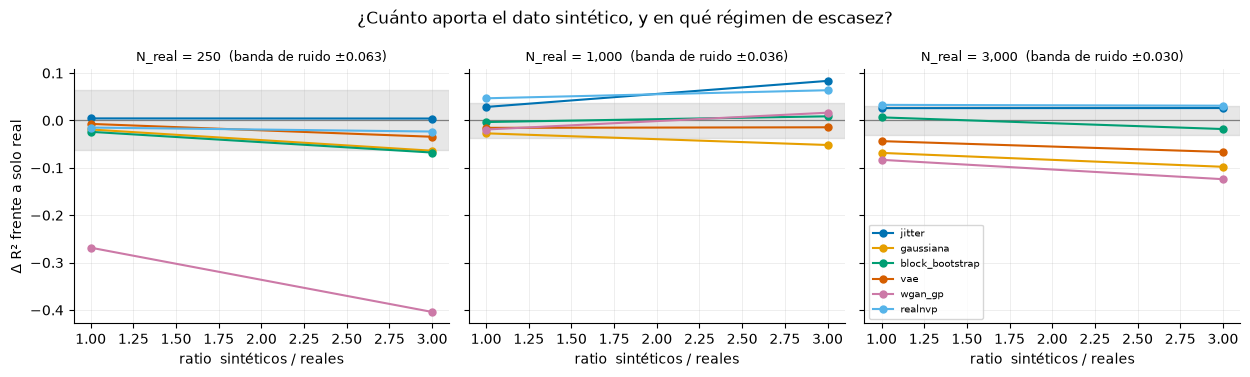

In [7]:
n_paneles = len(CONFIG_MALLA["n_reales"])
fig, axes = plt.subplots(1, n_paneles, figsize=(4.2 * n_paneles, 3.8), sharey=True)
axes = np.atleast_1d(axes)
colores = [PALETTE[c] for c in ("blue", "orange", "green", "vermillion", "purple", "sky")]
# La banda es la dispersión entre semillas del solo-real EN CADA N (ver §2.1.b),
# no el ±0,006 del notebook 02, que solo vale con las 102k ventanas completas.
UMBRAL_POR_N = umbral_ruido_por_n(df)

for ax, n in zip(axes, CONFIG_MALLA["n_reales"]):
    sub = delta[delta.n_real == n]
    u = UMBRAL_POR_N[n]
    ax.axhspan(-u, u, color=PALETTE["grey"], alpha=0.18, zorder=0)
    ax.axhline(0, color=PALETTE["grey"], lw=0.9)
    for col, g in zip(colores, GENERADORES):
        s = sub[sub.generador == g].sort_values("ratio")
        if len(s):
            ax.plot(s.ratio, s.delta_r2, "o-", color=col, lw=1.5, ms=5, label=g)
    ax.set_title(f"N_real = {n:,}  (banda de ruido ±{u:.3f})", fontsize=9)
    ax.set_xlabel("ratio  sintéticos / reales")
    _style(ax)
axes[0].set_ylabel("Δ R² frente a solo real")
axes[-1].legend(fontsize=7, loc="best")
fig.suptitle("¿Cuánto aporta el dato sintético, y en qué régimen de escasez?")
fig.tight_layout()
fig.savefig(cfg.fig_dir / "14_delta_r2_por_escasez.png", dpi=120, bbox_inches="tight")

### 2.3 Curvas de aprendizaje: R² frente a datos reales disponibles

La lectura complementaria — y la que reproduce la forma de la gráfica que el profesor
mostró en clase. La línea negra discontinua es el techo: el modelo entrenado con las
**102.406 ventanas reales completas** (notebook 02).

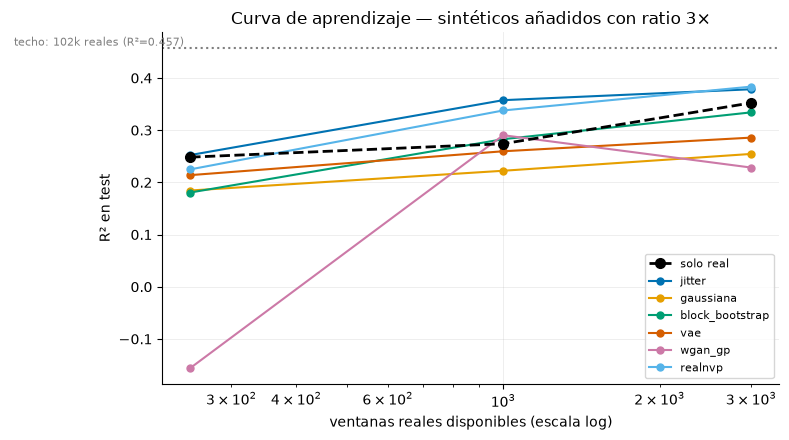

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
techo = np.mean([v["test_r2"] for v in ref["metricas_seeds"].values()])

base = resumen[resumen.generador == SOLO_REAL].sort_values("n_real")
ax.plot(base.n_real, base.test_r2_media, "o--", color="black", lw=2, ms=7,
        label="solo real", zorder=5)

RATIO_FOCO = 3 if 3 in CONFIG_MALLA["ratios"] else max(CONFIG_MALLA["ratios"])
for col, g in zip(colores, GENERADORES):
    s = resumen[(resumen.generador == g) & (resumen.ratio == RATIO_FOCO)].sort_values("n_real")
    if len(s):
        ax.plot(s.n_real, s.test_r2_media, "o-", color=col, lw=1.5, ms=5, label=g)

ax.axhline(techo, color=PALETTE["grey"], ls=":", lw=1.5)
ax.text(ax.get_xlim()[0], techo, f" techo: 102k reales (R²={techo:.3f})",
        va="bottom", fontsize=8, color=PALETTE["grey"])
ax.set_xscale("log")
ax.set_xlabel("ventanas reales disponibles (escala log)")
ax.set_ylabel("R² en test")
ax.set_title(f"Curva de aprendizaje — sintéticos añadidos con ratio {RATIO_FOCO}×")
ax.legend(fontsize=8)
_style(ax)
fig.tight_layout()
fig.savefig(cfg.fig_dir / "15_curva_aprendizaje.png", dpi=120, bbox_inches="tight")

### 2.4 ¿Predice la auditoría del notebook 03 el efecto downstream?

La pregunta que cierra el círculo del taller. En el notebook 03 medimos cada generador **sin
mirar el modelo downstream**, en dos ejes: **fidelidad** (discriminative AUC, curtosis,
clustering, distancias marginales y de dependencia) y **utilidad** (el ratio TSTR/TRTR, que
entrena un modelo *solo* con datos sintéticos). Si esas métricas anticipan la ganancia real
de la malla, se puede elegir generador midiendo el sintético, sin barrer una malla entera.

> **Los números se leen del CSV que el notebook 03 persiste**, no de una tabla copiada a
> mano. Es una precaución con historia: la malla **reentrena** cada generador en cada celda,
> así que si los hiperparámetros del 03 y los de `malla.construir_generador` se desviaran, una
> tabla escrita a mano seguiría mostrando las cifras viejas y la correlación de esta sección
> compararía dos cosas distintas sin avisar.

Se cruza contra el **delta pareado** (§2.1.b) y se calcula la correlación de rangos de
Spearman por nivel de escasez, porque el resultado depende críticamente del régimen. Ojo con
los **signos**: en `discriminative_auc`, las distancias (`w1_*`, `err_*`) menos es mejor, así
que una correlación **negativa** significa que la métrica predice bien; en `curtosis_x`,
`acf_abs_lag1` y `ratio_tstr_trtr` es al revés.

In [9]:
# Auditoría del notebook 03, leída del CSV que ese notebook persiste en su §6.
RUTA_AUD, RUTA_TSTR = cfg.out_dir / "auditoria_nb03.csv", cfg.out_dir / "tstr_nb03_resumen.csv"
if not RUTA_AUD.exists():
    raise FileNotFoundError(f"Falta {RUTA_AUD.name}: ejecuta antes el notebook 03, "
                            "que lo genera en su sección de persistencia.")

AUDITORIA_NB03 = pd.read_csv(RUTA_AUD, index_col=0).rename_axis("generador").reset_index()
if RUTA_TSTR.exists():   # la utilidad TSTR es también una métrica del 03
    AUDITORIA_NB03 = AUDITORIA_NB03.merge(
        pd.read_csv(RUTA_TSTR).rename(columns={"brazo": "generador"})[
            ["generador", "ratio_tstr_trtr"]], on="generador", how="left")

# Ordenadas por eje: fidelidad global, forma, dependencia y utilidad.
METRICAS = ["discriminative_auc", "w1_x_col_media", "curtosis_x", "acf_abs_lag1",
            "err_corr_xx_spearman", "err_corr_xx_pearson", "err_corr_xy", "ratio_tstr_trtr"]
METRICAS = [m for m in METRICAS if m in AUDITORIA_NB03]
print(f"Auditoría del nb03: {len(AUDITORIA_NB03)} generadores × {len(METRICAS)} métricas")

filas = []
for n in list(CONFIG_MALLA["n_reales"]) + ["todos"]:
    sub = par if n == "todos" else par[par.n_real == n]
    gan = sub.groupby("generador")["delta_medio"].mean().rename("ganancia").reset_index()
    c = AUDITORIA_NB03.merge(gan, on="generador")
    filas.append(pd.Series(c[METRICAS].corrwith(c["ganancia"], method="spearman"), name=n))
corr = pd.DataFrame(filas)
corr.index.name = "N_real"

print("\nCorrelación de Spearman entre la auditoría del nb03 y la ganancia downstream pareada:")
display(corr.round(2))

# El mejor predictor, en valor absoluto y sobre todos los regímenes a la vez
mejor = corr.loc["todos"].abs().idxmax()
print(f"Mejor predictor sobre el conjunto de la malla: {mejor} "
      f"(Spearman {corr.loc['todos', mejor]:+.2f})")

n_ref = CONFIG_MALLA["n_reales"][1] if len(CONFIG_MALLA["n_reales"]) > 1 else CONFIG_MALLA["n_reales"][0]
orden = (par[par.n_real == n_ref].groupby("generador")["delta_medio"].mean()
         .sort_values(ascending=False))
print(f"\nOrden de mérito downstream con N_real = {n_ref}:")
print("  " + "  >  ".join(orden.index))
print("Orden por curtosis en el nb03 (colas más realistas primero):")
print("  " + "  >  ".join(AUDITORIA_NB03.sort_values("curtosis_x", ascending=False).generador))
if "ratio_tstr_trtr" in AUDITORIA_NB03:
    print("Orden por utilidad TSTR en el nb03 (más información conservada primero):")
    print("  " + "  >  ".join(
        AUDITORIA_NB03.sort_values("ratio_tstr_trtr", ascending=False).generador))
print("\n(n = 6 generadores por celda: correlaciones indicativas, no concluyentes)")

Auditoría del nb03: 6 generadores × 8 métricas

Correlación de Spearman entre la auditoría del nb03 y la ganancia downstream pareada:


,discriminative_auc,w1_x_col_media,curtosis_x,acf_abs_lag1,err_corr_xx_spearman,err_corr_xx_pearson,err_corr_xy,ratio_tstr_trtr
N_real,,,,,,,,
250,-0.54,-0.54,0.14,0.31,-0.83,-0.20,-0.20,0.71
1000,-1.00,-1.00,0.83,0.77,-0.83,0.14,0.14,0.94
3000,-0.77,-0.77,0.60,0.71,-0.83,0.26,0.26,0.89
todos,-0.83,-0.83,0.66,0.77,-0.89,0.14,0.14,0.94


Mejor predictor sobre el conjunto de la malla: ratio_tstr_trtr (Spearman +0.94)

Orden de mérito downstream con N_real = 1000:
  jitter  >  realnvp  >  block_bootstrap  >  wgan_gp  >  vae  >  gaussiana
Orden por curtosis en el nb03 (colas más realistas primero):
  block_bootstrap  >  jitter  >  realnvp  >  wgan_gp  >  vae  >  gaussiana
Orden por utilidad TSTR en el nb03 (más información conservada primero):
  jitter  >  realnvp  >  block_bootstrap  >  vae  >  wgan_gp  >  gaussiana

(n = 6 generadores por celda: correlaciones indicativas, no concluyentes)



## 3 · Análisis crítico

Malla **REDUCIDA** ejecutada: 117 celdas (3 niveles de escasez × 3 ratios × 6 generadores ×
3 semillas), 2,8 minutos en una RTX 5070. Las cinco hipótesis se escribieron **antes** de
ver los resultados; se contrastan una a una, incluidas las que salieron mal.

### La escasez es real y el experimento tiene rango

| ventanas reales | R² en test (solo real) | sd entre semillas |
|---:|---:|---:|
| 250 | 0,248 | 0,063 |
| 1.000 | 0,274 | 0,036 |
| 3.000 | 0,352 | 0,030 |
| 102.406 (nb02) | **0,456** | 0,006 |

Hay recorrido de sobra —de 0,25 a 0,46— para que el dato sintético tenga dónde aportar.

### Contraste de hipótesis

**H1 · "El sintético solo ayuda en régimen de escasez" → REFUTADA en su forma esperada.**
Esperábamos el máximo beneficio con 250 ventanas. Ocurre lo contrario: con **N=250 no
ayuda nada** —ningún generador mejora de forma concluyente y cuatro empeoran— mientras que
el beneficio aparece con **N=1.000** (RealNVP +0,047, t=4,8) y se mantiene con N=3.000. Es
decir, **existe un suelo mínimo de datos reales por debajo del cual generar datos es
contraproducente**. Ese umbral está entre 250 y 1.000 ventanas. Es el hallazgo central del
taller y no estaba en el guion.

**H2 · "Existe un óptimo intermedio de proporción" → SIN EVIDENCIA todavía.** Al pasar de
ratio 1 a 3 los generadores útiles siguen mejorando (jitter +0,029 → +0,084 con N=1.000).
La degradación por exceso que anunció el profesor no aparece en el rango probado; haría
falta el ratio 10 de la malla COMPLETA para verla.

**H3 · "La gaussiana será difícil de batir" → REFUTADA ROTUNDAMENTE, y era mi apuesta con
confianza media-alta.** Es **el peor generador de los seis**: las 6 celdas son
significativamente negativas, hasta −0,098 con N=3.000. La predicción se apoyaba en que
los retornos son casi elípticos a nivel de covarianza y en que el beneficio sería
regularización pura. Los datos dicen lo contrario: **la fidelidad importa, y mucho**. Un
generador que no reproduce colas no solo no ayuda: **envenena** el entrenamiento.

### El resultado que cierra el círculo: la auditoría predice el efecto

Lo más valioso del taller no es qué generador gana, sino que **se puede saber cuál ganará
sin ejecutar la malla**. Correlación de rangos entre la auditoría del notebook 03 —que no
mira el modelo downstream en ningún momento— y la ganancia pareada de esta malla:

| N_real | AUC discrim. | W1 por columna | corr(X,X) rangos | curtosis | ACF de \|r\| | corr(X,X) Pearson | err_corr(X,y) | **ratio TSTR** |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 250 | −0,54 | −0,54 | **−0,83** | +0,14 | +0,31 | −0,20 | −0,20 | +0,71 |
| 1.000 | **−1,00** | **−1,00** | −0,83 | +0,83 | +0,77 | +0,14 | +0,14 | **+0,94** |
| 3.000 | −0,77 | −0,77 | −0,83 | +0,60 | +0,71 | +0,26 | +0,26 | +0,89 |
| todos | −0,83 | −0,83 | **−0,89** | +0,66 | +0,77 | +0,14 | +0,14 | **+0,94** |

Cuatro lecturas, y las tres primeras solo existen gracias a la ampliación de la auditoría:

1. **La utilidad TSTR es el mejor predictor de todos (+0,94).** Es el resultado más limpio
   del taller: entrenar el modelo **solo con datos sintéticos** y medir su R² sobre
   validación real —21 entrenamientos, 4 minutos en el notebook 03— predice el orden de
   mérito que esta malla de 117 celdas establece. No es sorprendente que funcione, pero sí
   que funcione *tan bien*: el TSTR mide utilidad en abundancia de sintético y la malla mide
   ganancia marginal en escasez de real, que son preguntas distintas.

   > Orden de la malla con N=1.000: `jitter > realnvp > block_bootstrap > wgan_gp > vae > gaussiana`
   > Orden del TSTR (nb03): `jitter > realnvp > block_bootstrap > vae > wgan_gp > gaussiana`
   >
   > Una sola inversión, entre los dos generadores que la malla declara **no concluyentes**.

2. **La distancia de Wasserstein por columna reproduce exactamente al discriminative AUC**
   (−0,54 / −1,00 / −0,77 / −0,83, cifra por cifra), porque induce el mismo orden. Pero el
   AUC exige entrenar un clasificador y la W1 son 60 ordenaciones. Es un predictor gratis.

3. **La correlación de rangos entre posiciones de la ventana es el único predictor que
   sobrevive a N=250.** Con 250 ventanas reales todas las demás métricas se desmoronan —el
   AUC cae a −0,54, la curtosis a +0,14— pero `corr(X,X)` en rangos se mantiene en −0,83 en
   los tres regímenes. Y su versión en **Pearson** vale +0,14: inútil, con el signo
   equivocado, porque la gaussiana reproduce la covarianza por construcción y aprueba esa
   métrica sin merecerlo. Exactamente la misma trampa que `err_corr(X,y)`, que da la cifra
   idéntica. El eje de dependencia multivariada no solo faltaba en la auditoría original:
   **la forma ingenua de medirlo habría sido engañosa**.

4. **El mecanismo es realismo distribucional, no regularización.** La curtosis y el
   clustering correlacionan con fuerza y con el signo esperado (+0,83 y +0,77 con N=1.000).
   Un generador ayuda en la medida en que reproduce la distribución.

Con N=250 casi todo se desmorona, y la explicación es la de H1: por debajo del umbral mínimo
de datos reales no hay nada que predecir, porque ningún generador funciona.

**H4 · "Las redes pierden justo donde harían falta" → CONFIRMADA para WGAN y VAE,
REFUTADA para el flow.** El WGAN-GP con N=250 es catastrófico: −0,27 y −0,40 sobre una
base de 0,248, es decir deja el R² en negativo — el modelo entrenado con sus muestras es
peor que predecir la media. El VAE empeora en 3 de 6 celdas y nunca mejora. Pero el
**RealNVP es el mejor generador de todos**, con 3 mejoras significativas. El matiz que sí
confirma H4: tampoco el flow funciona con N=250. Las redes generativas necesitan un mínimo
de datos que, por debajo, no tienen.

**H5 · "El jitter es difícil de batir" → CONFIRMADA.** Mejora en 2 celdas de forma
concluyente, **nunca empeora**, y es el único con ese perfil. Un generador que no aporta
información nueva —son ventanas reales con ruido— compite de tú a tú con tres arquitecturas
generativas. El RealNVP lo bate en consistencia estadística, no en magnitud.

### Señal secundaria: el sintético hace parar antes

La época de la que se conservan los pesos cae al añadir sintéticos (N=3.000: 32 → 20 → 15
al pasar de ratio 0 a 1 y 3). La validación **real** castiga cada vez antes al modelo
entrenado con la mezcla: confirma que los sintéticos empujan hacia una distribución que no
es la del problema.

### Limitaciones que hay que declarar en la presentación

1. **Tres semillas son pocas** para el régimen de escasez: 20 de 36 celdas quedan como no
   concluyentes. Con 5 semillas la mitad de ellas se resolvería. Es la mejora de mayor
   relación valor/coste, y cuesta minutos.
2. **Falta el ratio 10** para contrastar H2; está en la malla COMPLETA.
3. **El WGAN con N=250 tiene una desviación entre semillas de 0,27**, comparable a su
   propio efecto: su catástrofe es evidente en magnitud pero no alcanza significancia
   formal con 3 semillas.
4. Todo esto se mide sobre **un solo test** (2024–2026) y un solo problema financiero. No
   se puede extrapolar a otros horizontes ni a otros targets.

### Conclusión para la defensa

> Los datos sintéticos **sí** mejoran el modelo, pero solo por encima de un umbral mínimo
> de datos reales y solo si el generador reproduce las colas. Por debajo de ese umbral, y
> con generadores que gaussianizan la distribución, **el dato sintético destruye el
> modelo** en lugar de ayudarlo. El generador más sofisticado del taller (WGAN-GP) es el
> más peligroso, y el más trivial (ruido sobre datos reales) nunca hace daño.


## 4 · Persistencia

El CSV de la malla es el artefacto que alimenta la presentación. Se guarda en
`data/processed/` junto al resto, y se versiona.

In [10]:
resumen.to_csv(cfg.out_dir / f"malla_{MALLA.lower()}_resumen.csv", index=False)
delta.to_csv(cfg.out_dir / f"malla_{MALLA.lower()}_delta.csv", index=False)
print("Guardado:")
for p in sorted(cfg.out_dir.glob(f"malla_{MALLA.lower()}*.csv")):
    print(f"  {p.name}  ({p.stat().st_size/1024:.0f} KB)")

Guardado:
  malla_reducida.csv  (13 KB)
  malla_reducida_delta.csv  (4 KB)
  malla_reducida_resumen.csv  (3 KB)
